# Sampling strategies



prepare data: 
1. Filter1: translate dutch word to english word and then translate back to dutch, select the words with the original word same with the tranlated back words.
2. Filter2: select common words both in dutch norms and english norms
3. combine data: english and dutch norms
4. sampling (traing & test)

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [21]:
df_english = pd.read_csv("Sensorimotor_norms_12Oct2025.csv")
df_dutch = pd.read_excel("Words_Speed_Brysbaert_with_English_translation_and_back_translation.xlsx")
df_speedbrysbaert = pd.read_excel("SpeedBrysbaert_Norms.xlsx")

In [22]:
# Fliter1: translate before and back translate match
df_dutch['Include?'] = 1
df_dutch_filtered = df_dutch[df_dutch['Include?'] == 1]
len(df_dutch_filtered)

24036

In [23]:
# Filter2: select common words both in dutch norms and english norms
df_english["_eng_norm"] = df_english["Word"].astype(str).str.strip().str.lower()
df_dutch_filtered["_eng_norm"] = df_dutch_filtered["Deepl_translation_English"].astype(str).str.strip().str.lower()
# 内连接（只保留两边都有的词）
merged = pd.merge(df_english, df_dutch_filtered[["Original_word", "Deepl_translation_English", "_eng_norm"]],
                      on="_eng_norm", how="inner", validate="m:m")

In [24]:
merged.rename(columns={'Original_word':'Woord'}, inplace=True)
lancaster_speedbrysbaert_norms = pd.merge(merged, df_speedbrysbaert, on="Woord", how="inner")
lancaster_speedbrysbaert_norms = lancaster_speedbrysbaert_norms.drop(columns=['_eng_norm', 'Deepl_translation_English'], errors='ignore')
lancaster_speedbrysbaert_norms

,Word,Auditory.mean,Gustatory.mean,Haptic.mean,Interoceptive.mean,Olfactory.mean,Visual.mean,Foot_leg.mean,Hand_arm.mean,Head.mean,...,Prevalence,Length,Nsyl,N_phonemes,PoS,OLD20,DLP_RT,DLP_Acc,DCP_RT,DCP_Acc
0,AARDVARK,1.625,0.562,1.625,0.062,1.250,4.125,0.176,0.706,2.235,...,1.942224,10,3,8,N,2.60,639.248286,0.900000,1121.17,0.96
1,ABACUS,1.556,0.167,3.722,0.278,0.111,3.944,0.000,2.474,2.632,...,2.737364,7,2,6,N,2.80,621.580000,0.829268,994.43,0.99
2,ABANDON,0.941,0.118,0.294,2.118,0.059,2.176,1.100,0.700,2.450,...,2.849062,8,3,7,WW,1.35,476.680294,1.000000,948.73,1.00
3,ABBREVIATE,2.400,0.000,0.150,0.450,0.000,2.650,0.158,2.105,2.000,...,2.128239,8,3,7,WW,1.80,573.883333,0.878049,1091.43,0.99
4,ABBREVIATION,2.737,0.053,0.158,0.474,0.000,3.947,0.000,0.444,1.333,...,2.383672,9,3,8,N,2.35,530.200000,1.000000,1031.21,0.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18117,ZONE,1.167,0.389,0.611,0.833,0.444,3.000,0.867,0.933,2.467,...,3.191245,4,2,4,N,1.40,497.436216,0.951220,967.46,1.00
18118,ZONE,1.167,0.389,0.611,0.833,0.444,3.000,0.867,0.933,2.467,...,1.953973,5,2,5,Function,1.70,552.647568,0.950000,1184.90,0.93
18119,ZOO,2.933,0.067,2.067,0.733,2.933,3.533,2.692,1.692,3.923,...,2.721282,10,3,7,N,3.60,554.631795,1.000000,994.78,1.00
18120,ZOOM IN,0.474,0.105,0.316,0.158,0.105,3.789,0.300,1.650,3.150,...,2.252273,8,3,6,WW,2.00,555.722500,0.923077,1082.31,0.99


In [25]:
lancaster_speedbrysbaert_norms.to_excel("lancaster_speedbrysbaert_common_norms.xlsx", index=False)

### sample

In [26]:
# 50% from the 7861 words
random_state = 42
df_common = lancaster_speedbrysbaert_norms
df_common_selected, df_common_unselected = train_test_split(df_common, test_size=0.5, random_state=random_state)

print(f"Number of words in train set: {len(df_common_selected)}")
print(f"Number of words in test set: {len(df_common_unselected)}")

Number of words in train set: 9061
Number of words in test set: 9061


In [27]:
# 40% for test and 60% for training
random_state = 42
df_2 = df_common_selected
df_2_train, df_2_test = train_test_split(df_2, test_size=0.4, random_state=random_state)

print(f"Number of words in train set: {len(df_2_train)}")
print(f"Number of words in test set: {len(df_2_test)}")


Number of words in train set: 5436
Number of words in test set: 3625


In [28]:
df_2_test.to_excel('2_test_sensorimotor_random_sample.xlsx', index=False)
df_2_train.to_excel('2_train_sensorimotor_random_sample.xlsx', index=False)

## Data Distribution

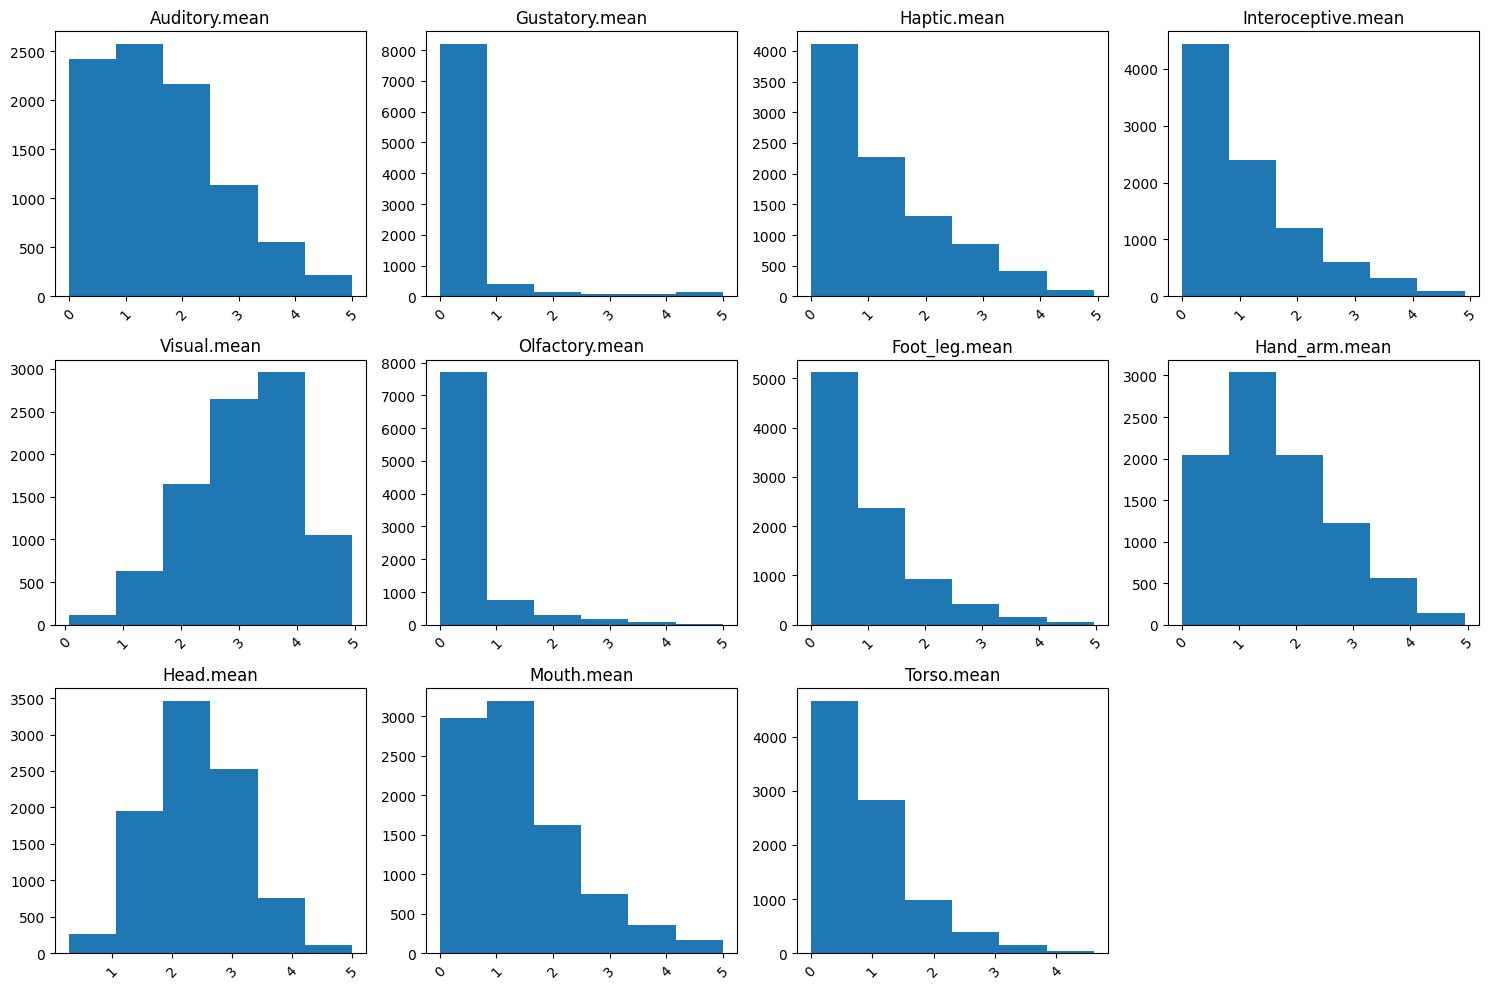

In [29]:
# the data distribution of English set
import matplotlib.pyplot as plt
cols = ['Auditory.mean','Gustatory.mean','Haptic.mean','Interoceptive.mean',
        'Visual.mean','Olfactory.mean','Foot_leg.mean','Hand_arm.mean',
        'Head.mean','Mouth.mean','Torso.mean']
fig, axes = plt.subplots(3, 4, figsize=(15, 10))  # 增大 figsize
axes = axes.flatten()
for ax, col in zip(axes, cols):
    df_common_selected[col].dropna().hist(bins=6, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(False)
# 关闭多余子图（第 12 个）
if len(cols) < len(axes):
    for ax in axes[len(cols):]:
        ax.set_visible(False)
plt.tight_layout()
plt.show()

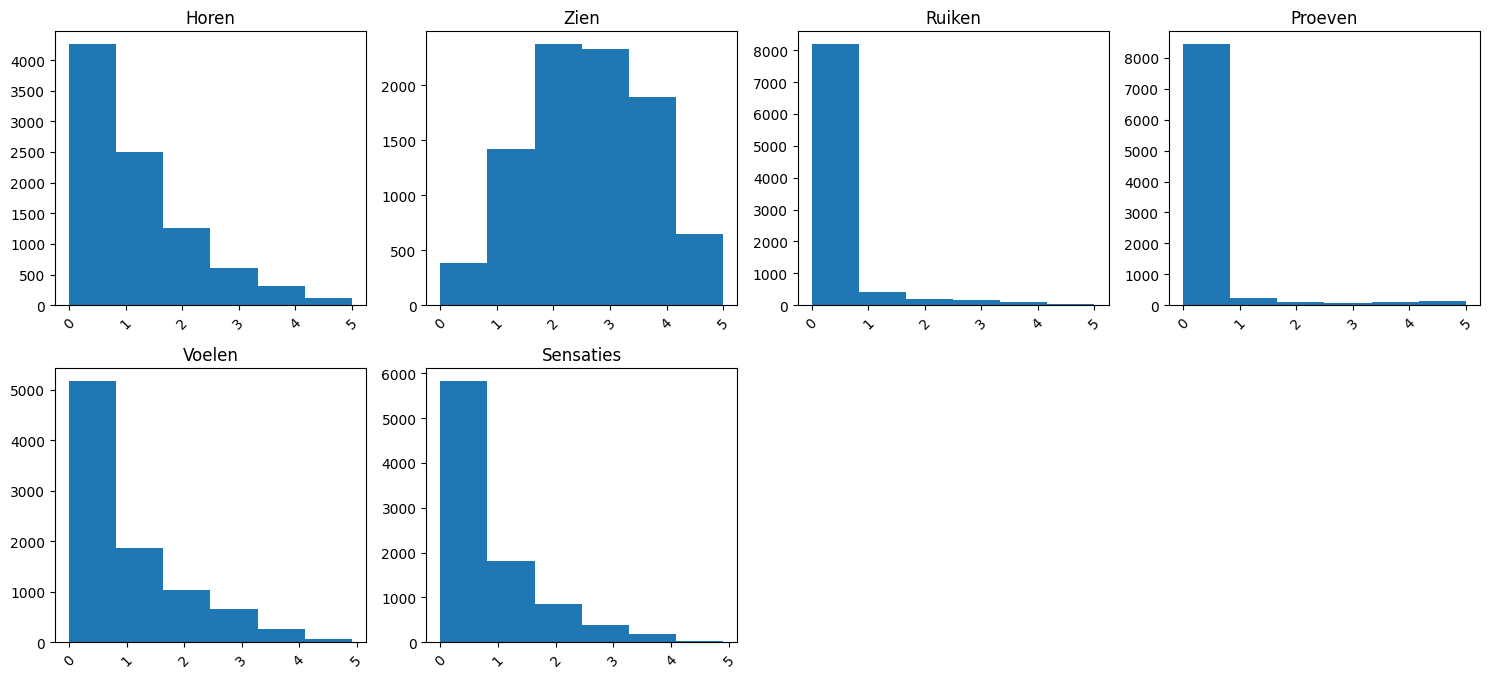

In [30]:
# the data distribution of dutch set
import matplotlib.pyplot as plt
cols = ['Horen', 'Zien', 'Ruiken', 'Proeven', 'Voelen', 'Sensaties']
fig, axes = plt.subplots(3, 4, figsize=(15, 10))  # 增大 figsize
axes = axes.flatten()
for ax, col in zip(axes, cols):
    df_common_selected[col].dropna().hist(bins=6, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(False)
# 关闭多余子图（第 12 个）
if len(cols) < len(axes):
    for ax in axes[len(cols):]:
        ax.set_visible(False)
plt.tight_layout()
plt.show()